# Person 2 - Trapezoidal Rule

Numerical Estimation of River Cross-Sectional Area using the Trapezoidal Rule

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. River depth dataset (from Person 1)

Same dataset as the cross-section profile: depth measured every 2 meters across a 20 meter wide river, 11 points (10 intervals).

In [2]:
distance = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
depth = np.array([0, 1.15, 2.5, 3.25, 3.85, 3.5, 3.1, 2.15, 1.6, 0.75, 0])

n = len(distance) - 1        # number of intervals
h = distance[1] - distance[0]  # uniform spacing (2 m)

print("Number of points:", len(distance))
print("Number of intervals (n):", n)
print("Spacing (h):", h, "m")

Number of points: 11
Number of intervals (n): 10
Spacing (h): 2 m


## 2. Trapezoidal Rule theory

For $n$ intervals of equal width $h$, the Trapezoidal Rule estimates the area under the curve as:

$$A \approx \frac{h}{2}\left[y_0 + 2\sum_{i=1}^{n-1} y_i + y_n\right]$$

Geometrically, each interval is treated as a trapezoid between two consecutive depth measurements, and the total area is the sum of all trapezoid areas.

In [3]:
# Manual implementation of the Trapezoidal Rule (composite form)
def trapezoidal_rule(x, y):
    h = x[1] - x[0]
    total = y[0] + y[-1] + 2 * np.sum(y[1:-1])
    return (h / 2) * total

area_manual = trapezoidal_rule(distance, depth)
print(f"Cross-sectional area (manual formula): {area_manual:.4f} m^2")

Cross-sectional area (manual formula): 43.7000 m^2


## 3. Verification with `np.trapz`

Cross-checking the manual formula against NumPy's built-in trapezoidal integrator.

In [4]:
area_numpy = np.trapezoid(depth, distance)  # np.trapz was removed in NumPy 2.0+
print(f"Cross-sectional area (np.trapezoid):    {area_numpy:.4f} m^2")
print(f"Difference from manual calculation: {abs(area_manual - area_numpy):.2e} m^2")

Cross-sectional area (np.trapezoid):    43.7000 m^2
Difference from manual calculation: 7.11e-15 m^2


## 4. Per-interval breakdown

Area contributed by each individual trapezoid, useful for showing the working step-by-step.

In [5]:
print(f"{'Interval':<12}{'x_i (m)':<10}{'x_i+1 (m)':<12}{'Trapezoid Area (m^2)':<22}")
interval_areas = []
for i in range(n):
    a_i = (h / 2) * (depth[i] + depth[i + 1])
    interval_areas.append(a_i)
    print(f"{i+1:<12}{distance[i]:<10}{distance[i+1]:<12}{a_i:<22.4f}")

print(f"\nSum of interval areas: {sum(interval_areas):.4f} m^2")

Interval    x_i (m)   x_i+1 (m)   Trapezoid Area (m^2)  
1           0         2           1.1500                
2           2         4           3.6500                
3           4         6           5.7500                
4           6         8           7.1000                
5           8         10          7.3500                
6           10        12          6.6000                
7           12        14          5.2500                
8           14        16          3.7500                
9           16        18          2.3500                
10          18        20          0.7500                

Sum of interval areas: 43.7000 m^2


## 5. Visualization

The river cross-section with the trapezoids overlaid, showing how the Trapezoidal Rule approximates the true area.

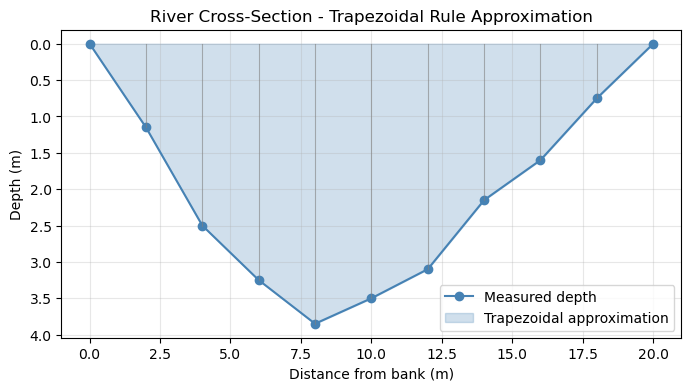

In [6]:
plt.figure(figsize=(8, 4))

# Actual profile
plt.plot(distance, depth, marker='o', color='steelblue', label='Measured depth')

# Trapezoid edges (vertical lines at each measurement point)
for xi, yi in zip(distance, depth):
    plt.plot([xi, xi], [0, yi], color='gray', linewidth=0.8, alpha=0.6)

plt.fill_between(distance, depth, color='steelblue', alpha=0.25, label='Trapezoidal approximation')

plt.gca().invert_yaxis()
plt.title("River Cross-Section - Trapezoidal Rule Approximation")
plt.xlabel("Distance from bank (m)")
plt.ylabel("Depth (m)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Output for the group

**Estimated cross-sectional area (Trapezoidal Rule): see printed value above.**

This value is passed to Person 3 for comparison against Simpson's 1/3 Rule, and can be discussed in terms of accuracy (Trapezoidal Rule assumes straight lines between points, so it tends to underestimate area where the profile curves, e.g. near the deepest point).